In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float64')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test_original, y_test_original) = tf.keras.datasets.mnist.load_data()
x_train, x_test_noisy, y_train, y_test_noisy       = train_test_split(x_train, y_train, test_size=1/6, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 28, 28, 1)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 28, 28, 1)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 28, 28, 1)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 28, 28, 1)


x_train_original                           = x_train_original.astype('float64')
x_train_noisy                              = x_train_noisy.astype('float64')
x_test_original                            = x_test_original.astype('float64')
x_test_noisy                               = x_test_noisy.astype('float64')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

print('x_train_original', x_train_original.shape)
print('x_train_noisy', x_train_noisy.shape)
print('x_test_original', x_test_original.shape)
print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.3
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss


x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test_noisy', x_test_noisy.shape)
# plt.figure()
# plt.imshow(x_test_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_test_original', x_test_original.shape)
# plt.figure()
# plt.imshow(x_test_original[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 10 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 10
batch_size        = 32
no_epochs         = 50
verbosity         = 1
beta_01           = 1e-5 # Lagrange Multiplier in Loss Function
beta_02           = 2 - 1e-5
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
print('y_train.shape', y_train.shape)
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.latent_dim   = latent_dim
        self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
        self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
        self.flatten      = Flatten()
        self.dense_10     = Dense(1024, activation='relu')
        self.dropout      = Dropout(0.4)
        self.lineardense  = Dense(2*latent_dim, name='latent_mu')

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
        conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
        maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
        flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout1_enc_s1   = self.dropout(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout1_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(100, activation='relu')
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        dense2_dec_s1     = self.dense_02(dense1_dec_s1)
        return dense2_dec_s1
######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-4)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder_01 = Encoder(latent_dim_01)
        self.decoder_01 = Decoder()
        self.encoder_02 = Encoder(latent_dim_02)
        self.decoder_02 = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        # mu_1         = tf.reshape(mu, [-1, latent_dim])
        # logvar_1     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float64)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu_01, logvar_01 = self.encoder_01(input_vae)
        latent_space_01  = self.sampling(mu_01, logvar_01, latent_dim_01)     # (batch_size, latent_dim)
        predictions_01   = self.decoder_01(latent_space_01)

        mu_02, logvar_02 = self.encoder_02(input_vae)
        latent_space_02  = self.sampling(mu_02, logvar_02, latent_dim_02)
        # predictions_02   = self.decoder_02(tf.reshape(tf.concat([latent_space_01, latent_space_02], axis = 1),
        #                                        [latent_space_01.shape[0], latent_dim_01+latent_dim_02]))
        predictions_02   = self.decoder_02(tf.concat([latent_space_01, latent_space_02], axis = 1))
        return mu_02, logvar_02, predictions_01, predictions_02


def Loss_02(mu, logvar, labels, predictions_01, predictions_02):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    D_KL      = (-1/2) * tf.math.reduce_mean(1 + logvar - tf.math.square(mu) - tf.math.exp(logvar))  # mu, logvar sizes:(batch, latent_dim)

    return D_KL + beta_01 * logqx_u_01 + beta_02 * logqx_u_02, D_KL, logqx_u_01, logqx_u_02



# train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')

# test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_original_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_01')
test_original_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_02')

test_noisy_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_01')
test_noisy_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_02')

# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu_02, logvar_02, predictions_01, predictions_02 = model(images)
        loss, D_KL, logqx_u_01, logqx_u_02 = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss_02(loss)
    train_accuracy_01(labels, tf.nn.softmax(predictions_01))
    train_accuracy_02(labels, tf.nn.softmax(predictions_02))#Predictions&Labels size:(batch,no_sampling,10)

# @tf.function
def test_original_step(model, images, labels):
    mu_02, logvar_02, predictions_01, predictions_02 = model(images)
    t_loss, D_KL, logqx_u_01, logqx_u_02 = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # print('D_KL', D_KL)
    # print('logqx_u_01', logqx_u_01)
    # print('logqx_u_02', logqx_u_02)
    # test_loss_02(t_loss)
    test_original_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_original_accuracy_02(labels, tf.nn.softmax(predictions_02))

# @tf.function
def test_noisy_step(model, images, labels):
    mu_02, logvar_02, predictions_01, predictions_02 = model(images)
    # t_loss = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # test_loss_02(t_loss)
    test_noisy_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_noisy_accuracy_02(labels, tf.nn.softmax(predictions_02))


model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model_02, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model_02, test_images, test_labels)
        template = 'Epoch {}, train_accuracy_01: {}, train_accuracy_02: {},  test_original_accuracy_01: {},  test_original_accuracy_02: {}, test_noisy_accuracy_01: {}, test_noisy_accuracy_02: {}'
        print(template.format(epoch+1, train_accuracy_01.result()*100,
                              train_accuracy_02.result()*100,
                              test_original_accuracy_01.result()*100,
                              test_original_accuracy_02.result()*100,
                              test_noisy_accuracy_01.result()*100,
                              test_noisy_accuracy_02.result()*100))
        if epoch == 0:
          Two_Free_01  = np.array([test_original_accuracy_01.result()*100])
          Two_Noisy_01 = np.array([test_noisy_accuracy_01.result()*100])
          Two_Free_02  = np.array([test_original_accuracy_02.result()*100])
          Two_Noisy_02 = np.array([test_noisy_accuracy_02.result()*100])
        else:
          Two_Free_01  = np.concatenate((Two_Free_01, np.array([test_original_accuracy_01.result()*100])), axis=0)
          Two_Noisy_01 = np.concatenate((Two_Noisy_01, np.array([test_noisy_accuracy_01.result()*100])), axis=0)
          Two_Free_02  = np.concatenate((Two_Free_02, np.array([test_original_accuracy_02.result()*100])), axis=0)
          Two_Noisy_02 = np.concatenate((Two_Noisy_02, np.array([test_noisy_accuracy_02.result()*100])), axis=0)


11493376/11490434 [==============================] - 0s 0us/step
x_train_original (25000, 28, 28, 1)
x_train_noisy (25000, 28, 28, 1)
x_test_original (10000, 28, 28, 1)
x_test_noisy (10000, 28, 28, 1)
y_train.shape (50000,)
##########################################################################################################################################


KeyboardInterrupt: ignored

In [ ]:
print('Two_Free_01', tf.round(Two_Free_01*1000)/1000)
print('Two_Noisy_01', tf.round(Two_Noisy_01*1000)/1000)
print('Two_Free_02', tf.round(Two_Free_02*1000)/1000)
print('Two_Noisy_02', tf.round(Two_Noisy_02*1000)/1000)

Two_Free_01 tf.Tensor(
[95.54  96.525 97.06  97.385 97.618 97.802 97.923 98.059 98.158 98.235
 98.306 98.353 98.402 98.452 98.495 98.516 98.551 98.557 98.576 98.595
 98.615 98.633 98.65  98.665 98.682 98.697 98.705 98.719 98.725 98.735
 98.744 98.756 98.766 98.773 98.782 98.789 98.795 98.798 98.807 98.816
 98.824 98.833 98.843 98.852 98.856 98.862 98.868 98.874 98.88  98.886], shape=(50,), dtype=float64)
Two_Noisy_01 tf.Tensor(
[93.39  94.78  95.527 95.968 96.268 96.54  96.704 96.891 97.031 97.135
 97.21  97.271 97.325 97.393 97.453 97.501 97.542 97.566 97.593 97.625
 97.66  97.682 97.712 97.728 97.749 97.777 97.785 97.805 97.819 97.838
 97.856 97.873 97.888 97.898 97.913 97.924 97.937 97.944 97.961 97.977
 97.992 98.003 98.015 98.028 98.031 98.042 98.053 98.064 98.075 98.086], shape=(50,), dtype=float64)
Two_Free_02 tf.Tensor(
[96.62  97.185 97.563 97.815 98.008 98.137 98.219 98.322 98.398 98.455
 98.503 98.539 98.573 98.609 98.638 98.656 98.678 98.674 98.688 98.702
 98.721 98.73  98.

In [ ]:
print(1e-2)

0.01


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test_original, y_test_original) = tf.keras.datasets.mnist.load_data()
x_train, x_test_noisy, y_train, y_test_noisy       = train_test_split(x_train, y_train, test_size=1/6, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 28, 28, 1)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 28, 28, 1)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 28, 28, 1)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 28, 28, 1)


x_train_original                           = x_train_original.astype('float32')
x_train_noisy                              = x_train_noisy.astype('float32')
x_test_original                            = x_test_original.astype('float32')
x_test_noisy                               = x_test_noisy.astype('float32')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

print('x_train_original', x_train_original.shape)
print('x_train_noisy', x_train_noisy.shape)
print('x_test_original', x_test_original.shape)
print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.1
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)

  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss

# plt.figure()
# plt.imshow(x_train_noisy[4778].reshape(28,28), cmap='Greys')
# x_train_original     = Noisy(x_train_original)
# x_train_original     = np.clip(x_train_original, 0, 1)


# x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
# x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)


# plt.figure()
# plt.imshow(x_train_noisy[4778].reshape(28,28), cmap='Greys')


x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
x_train, y_train  = Shuffle(x_train, y_train)

# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test', x_test.shape)
# plt.figure()
# plt.imshow(x_test[4777].reshape(28,28), cmap='Greys')



# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim        = 20 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
batch_size        = 32
no_epochs         = 50
verbosity         = 1
beta              = 1e-3 # Lagrange Multiplier in Loss Function
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).shuffle(x_val.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)
# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
        self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
        self.flatten      = Flatten()
        self.dense_10     = Dense(1024, activation='relu')
        self.dropout      = Dropout(0.4)
        self.lineardense  = Dense(2*latent_dim, name='latent_mu')

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
        conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
        maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
        flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout1_enc_s1   = self.dropout(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout1_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(100, activation='relu')
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        dense2_dec_s1     = self.dense_02(dense1_dec_s1)
        return dense2_dec_s1

# # =================================================================================================================
# # VAE
# # =================================================================================================================
class VAE (tf.keras.Model):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def sampling (self, mu, logvar):
        mu_1         = tf.reshape(mu, [-1, latent_dim])
        logvar_1     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu_1.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu_1 + tf.math.exp(logvar_1 / 2) * eps

    def call(self, input_vae):
        mu, logvar = self.encoder(input_vae)
        predictions = self.decoder(self.sampling(mu, logvar))
        return mu, logvar, predictions

# # =================================================================================================================
# # LOSS
# # =================================================================================================================

def Loss(mu, logvar, labels, predictions):  # prediction size:(batch, M, 10)

    cross_ent  = tf.nn.softmax_cross_entropy_with_logits(logits=predictions, labels=labels) #cross_ent size:(batch, M)
    logqx_u    = tf.math.reduce_mean(cross_ent)
    KL_loss    = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL       = (-1/2) * tf.math.reduce_mean(KL_loss)
    # print('D_KL', D_KL)
    # print('logqx_u', logqx_u)

    # global rate
    # global relevance
    # rate       += D_KL
    # relevance  += logqx_u
    # Total_loss = D_KL - beta * logqx_u
    # Total_loss =   D_KL - beta * logqx_u

    # print('labels',labels.shape)
    # print('predictions',predictions.shape)
    # print('cross_ent',cross_ent.shape)
    # print('logqx_u',logqx_u.shape)
    # print('KL_loss',KL_loss.shape)
    # print('D_KL',D_KL.shape)
          # qqq=0
    return D_KL + logqx_u, D_KL, logqx_u



# train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')

# test_loss = tf.keras.metrics.Mean(name='test_loss')
test_original_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy')
test_noisy_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy')

# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions = model(images)
        loss, D_KL, logqx_u = Loss(mu, logvar, labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss(loss)
    train_accuracy(labels, tf.nn.softmax(predictions)) # Predictions & Labels size:(batch,M,10)

# @tf.function
def test_original_step(model, images, labels):
    mu, logvar, predictions = model(images)
    loss, D_KL, logqx_u = Loss(mu, logvar, labels, predictions)
    # print('D_KL', D_KL)
    # print('logqx_u', logqx_u)
    # test_loss(t_loss)
    test_original_accuracy(labels, tf.nn.softmax(predictions))

# @tf.function
def test_noisy_step(model, images, labels):
    mu, logvar, predictions = model(images)
    # t_loss = Loss(mu, logvar, labels, predictions)
    # test_loss(t_loss)
    test_noisy_accuracy(labels, tf.nn.softmax(predictions))

optimizer = tf.optimizers.Adam(learning_rate=1e-4)




# Create an instance of the model
model = VAE()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model, test_images, test_labels)
        template = 'Epoch {}, train_accuracy: {}, test_original_accuracy: {},  test_noisy_accuracy: {}'
        print(template.format(epoch+1, train_accuracy.result()*100,
                              test_original_accuracy.result()*100,
                              test_noisy_accuracy.result()*100))
        if epoch == 0:
          One_Free  = np.array([test_original_accuracy.result()*100])
          One_Noisy = np.array([test_noisy_accuracy.result()*100])
        else:
          One_Free  = np.concatenate((One_Free, np.array([test_original_accuracy.result()*100])), axis=0)
          One_Noisy = np.concatenate((One_Noisy, np.array([test_noisy_accuracy.result()*100])), axis=0)

x_train_original (25000, 28, 28, 1)
x_train_noisy (25000, 28, 28, 1)
x_test_original (10000, 28, 28, 1)
x_test_noisy (10000, 28, 28, 1)
Epoch 1, train_accuracy: 85.72999572753906, test_original_accuracy: 94.9800033569336,  test_noisy_accuracy: 91.91999816894531
Epoch 2, train_accuracy: 90.36800384521484, test_original_accuracy: 95.19000244140625,  test_noisy_accuracy: 91.30999755859375
Epoch 3, train_accuracy: 92.13265991210938, test_original_accuracy: 95.44666290283203,  test_noisy_accuracy: 91.27333068847656
Epoch 4, train_accuracy: 93.14849853515625, test_original_accuracy: 95.60749816894531,  test_noisy_accuracy: 91.13999938964844
Epoch 5, train_accuracy: 93.80760192871094, test_original_accuracy: 95.80599975585938,  test_noisy_accuracy: 91.25800323486328
Epoch 6, train_accuracy: 94.2979965209961, test_original_accuracy: 96.0816650390625,  test_noisy_accuracy: 91.60833740234375
Epoch 7, train_accuracy: 94.67742919921875, test_original_accuracy: 96.18571472167969,  test_noisy_accura

In [ ]:
print('One_Free', tf.round(One_Free*1000)/1000)
print('One_Noisy', tf.round(One_Noisy*1000)/1000)

One_Free tf.Tensor(
[94.98  95.19  95.447 95.608 95.806 96.082 96.186 96.258 96.399 96.48
 96.498 96.537 96.55  96.583 96.591 96.618 96.652 96.708 96.724 96.758
 96.757 96.811 96.833 96.875 96.904 96.948 96.997 97.022 97.067 97.101
 97.135 97.166 97.169 97.18  97.194 97.217 97.25  97.269 97.293 97.303
 97.3   97.323 97.329 97.342 97.356 97.372 97.387 97.389 97.395 97.411], shape=(50,), dtype=float32)
One_Noisy tf.Tensor(
[91.92  91.31  91.273 91.14  91.258 91.608 91.606 91.635 91.808 91.856
 91.836 91.852 91.794 91.77  91.751 91.714 91.783 91.864 91.825 91.885
 91.788 91.885 91.869 91.919 91.929 92.02  92.106 92.136 92.214 92.268
 92.359 92.398 92.357 92.359 92.358 92.41  92.474 92.479 92.53  92.503
 92.445 92.496 92.496 92.516 92.548 92.575 92.607 92.614 92.631 92.667], shape=(50,), dtype=float32)


x_train_noisy (25000, 28, 28, 1)
y_train_noisy 3
x_train_original (25000, 28, 28, 1)


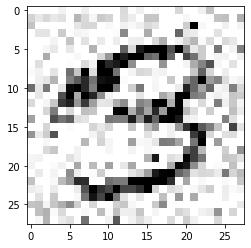

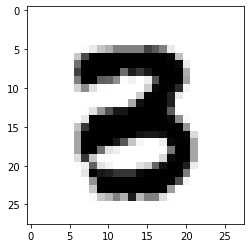

In [ ]:
print('x_train_noisy', x_train_noisy.shape)
print('y_train_noisy', y_train_noisy[4778])
plt.figure()
plt.imshow(x_train_noisy[4778].reshape(28,28), cmap='Greys')

print('x_train_original', x_train_original.shape)
plt.figure()
plt.imshow(x_train_original[4772].reshape(28,28), cmap='Greys')

In [ ]:
##############################################################################################################
########################################## T=3 ###############################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float64')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test_original, y_test_original) = tf.keras.datasets.mnist.load_data()
x_train, x_test_noisy, y_train, y_test_noisy       = train_test_split(x_train, y_train, test_size=1/6, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 28, 28, 1)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 28, 28, 1)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 28, 28, 1)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 28, 28, 1)


x_train_original                           = x_train_original.astype('float64')
x_train_noisy                              = x_train_noisy.astype('float64')
x_test_original                            = x_test_original.astype('float64')
x_test_noisy                               = x_test_noisy.astype('float64')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

print('x_train_original', x_train_original.shape)
print('x_train_noisy', x_train_noisy.shape)
print('x_test_original', x_test_original.shape)
print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.3
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss


x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test_noisy', x_test_noisy.shape)
# plt.figure()
# plt.imshow(x_test_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_test_original', x_test_original.shape)
# plt.figure()
# plt.imshow(x_test_original[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 7 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 7
latent_dim_03     = 7
batch_size        = 32
no_epochs         = 50
verbosity         = 1
beta_01           = 1 # Lagrange Multiplier in Loss Function
beta_02           = 1
beta_03           = 1
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.latent_dim   = latent_dim
        self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
        self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
        self.flatten      = Flatten()
        self.dense_10     = Dense(1024, activation='relu')
        self.dropout      = Dropout(0.4)
        self.lineardense  = Dense(2*latent_dim, name='latent_mu')

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
        conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
        maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
        flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout1_enc_s1   = self.dropout(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout1_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(100, activation='relu')
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        dense2_dec_s1     = self.dense_02(dense1_dec_s1)
        return dense2_dec_s1
######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-4)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder_01 = Encoder(latent_dim_01)
        self.decoder_01 = Decoder()
        self.encoder_02 = Encoder(latent_dim_02)
        self.decoder_02 = Decoder()
        self.encoder_03 = Encoder(latent_dim_03)
        self.decoder_03 = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        # mu_1         = tf.reshape(mu, [-1, latent_dim])
        # logvar_1     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float64)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu_01, logvar_01 = self.encoder_01(input_vae)
        latent_space_01  = self.sampling(mu_01, logvar_01, latent_dim_01)     # (batch_size, latent_dim)
        predictions_01   = self.decoder_01(latent_space_01)

        mu_02, logvar_02 = self.encoder_02(input_vae)
        latent_space_02  = self.sampling(mu_02, logvar_02, latent_dim_02)
        predictions_02   = self.decoder_02(tf.concat([latent_space_01, latent_space_02], axis = 1))

        mu_03, logvar_03 = self.encoder_03(input_vae)
        latent_space_03  = self.sampling(mu_03, logvar_03, latent_dim_03)
        predictions_03   = self.decoder_03(tf.concat([latent_space_01, latent_space_02, latent_space_03], axis = 1))

        return mu_03, logvar_03, predictions_01, predictions_02, predictions_03


def Loss_02(mu, logvar, labels, predictions_01, predictions_02, predictions_03):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    cross_ent_03 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_03, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_03   = tf.math.reduce_mean(cross_ent_03)
    D_KL      = (-1/2) * tf.math.reduce_mean(1 + logvar - tf.math.square(mu) - tf.math.exp(logvar))  # mu, logvar sizes:(batch, latent_dim)

    return D_KL + beta_01 * logqx_u_01 + beta_02 * logqx_u_02 + beta_03 * logqx_u_03, D_KL, logqx_u_01, logqx_u_02, logqx_u_03



# train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')
train_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_03')
# test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_original_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_01')
test_original_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_02')
test_original_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_03')
test_noisy_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_01')
test_noisy_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_02')
test_noisy_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_03')
# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
        loss, D_KL, logqx_u_01, logqx_u_02, logqx_u_03 = Loss_02(mu_03, logvar_03, labels, predictions_01, predictions_02, predictions_03)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss_02(loss)
    train_accuracy_01(labels, tf.nn.softmax(predictions_01))
    train_accuracy_02(labels, tf.nn.softmax(predictions_02))#Predictions&Labels size:(batch,no_sampling,10)
    train_accuracy_03(labels, tf.nn.softmax(predictions_03))

# @tf.function
def test_original_step(model, images, labels):
    mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
    # t_loss, D_KL, logqx_u_01, logqx_u_02, logqx_u_03 = Loss_02(mu_03, logvar_03, labels, predictions_01, predictions_02, predictions_03)
    # print('D_KL', D_KL)
    # print('logqx_u_01', logqx_u_01)
    # print('logqx_u_02', logqx_u_02)
    # test_loss_02(t_loss)
    test_original_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_original_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_original_accuracy_03(labels, tf.nn.softmax(predictions_03))

# @tf.function
def test_noisy_step(model, images, labels):
    mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
    # t_loss = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # test_loss_02(t_loss)
    test_noisy_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_noisy_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_noisy_accuracy_03(labels, tf.nn.softmax(predictions_03))


model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model_02, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model_02, test_images, test_labels)
        template = 'Epoch {}, train_accuracy_01: {}, train_accuracy_02: {}, train_accuracy_03: {}, test_original_accuracy_01: {},  test_original_accuracy_02: {}, test_original_accuracy_03: {}, test_noisy_accuracy_01: {}, test_noisy_accuracy_02: {}, test_noisy_accuracy_03: {}'
        print(template.format(epoch+1, train_accuracy_01.result()*100,
                              train_accuracy_02.result()*100,
                              train_accuracy_03.result()*100,
                              test_original_accuracy_01.result()*100,
                              test_original_accuracy_02.result()*100,
                              test_original_accuracy_03.result()*100,
                              test_noisy_accuracy_01.result()*100,
                              test_noisy_accuracy_02.result()*100,
                              test_noisy_accuracy_03.result()*100))
        if epoch == 0:
          Two_Free_01  = np.array([test_original_accuracy_01.result()*100])
          Two_Noisy_01 = np.array([test_noisy_accuracy_01.result()*100])
          Two_Free_02  = np.array([test_original_accuracy_02.result()*100])
          Two_Noisy_02 = np.array([test_noisy_accuracy_02.result()*100])
          Two_Free_03  = np.array([test_original_accuracy_03.result()*100])
          Two_Noisy_03 = np.array([test_noisy_accuracy_03.result()*100])
        else:
          Two_Free_01  = np.concatenate((Two_Free_01, np.array([test_original_accuracy_01.result()*100])), axis=0)
          Two_Noisy_01 = np.concatenate((Two_Noisy_01, np.array([test_noisy_accuracy_01.result()*100])), axis=0)
          Two_Free_02  = np.concatenate((Two_Free_02, np.array([test_original_accuracy_02.result()*100])), axis=0)
          Two_Noisy_02 = np.concatenate((Two_Noisy_02, np.array([test_noisy_accuracy_02.result()*100])), axis=0)
          Two_Free_03  = np.concatenate((Two_Free_03, np.array([test_original_accuracy_03.result()*100])), axis=0)
          Two_Noisy_03 = np.concatenate((Two_Noisy_03, np.array([test_noisy_accuracy_03.result()*100])), axis=0)


x_train_original (25000, 28, 28, 1)
x_train_noisy (25000, 28, 28, 1)
x_test_original (10000, 28, 28, 1)
x_test_noisy (10000, 28, 28, 1)
##########################################################################################################################################
Epoch 1, train_accuracy_01: 84.07, train_accuracy_02: 87.356, train_accuracy_03: 86.75399999999999, test_original_accuracy_01: 95.08,  test_original_accuracy_02: 96.72, test_original_accuracy_03: 96.34, test_noisy_accuracy_01: 92.66, test_noisy_accuracy_02: 94.14, test_noisy_accuracy_03: 94.27
Epoch 2, train_accuracy_01: 89.949, train_accuracy_02: 92.052, train_accuracy_03: 91.73, test_original_accuracy_01: 96.255,  test_original_accuracy_02: 97.395, test_original_accuracy_03: 97.24000000000001, test_noisy_accuracy_01: 94.23, test_noisy_accuracy_02: 95.35, test_noisy_accuracy_03: 95.565
Epoch 3, train_accuracy_01: 92.31933333333333, train_accuracy_02: 93.948, train_accuracy_03: 93.72733333333333, test_original_accur

KeyboardInterrupt: ignored